# Feature selection

# Setup Code
## Environment

In [1]:
### use brd4

import sys

print(sys.executable)

/home/oskar/anaconda3/envs/brd4/bin/python


## Imports

In [2]:
### Standard imports
import copy
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn as sk
from rdkit import RDLogger
from tqdm import tqdm

In [3]:
### Specific imports
import optuna
import torch
import torchmetrics
from torch.utils.data import DataLoader, TensorDataset

/home/oskar/anaconda3/envs/brd4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Jupyter Settings

In [4]:
### Random seed - using the same seed for robustness
SEED = 42
np.random.seed(SEED)

### NumPy arrays - floats
np.set_printoptions(
    precision=2,  # round values
    suppress=True,
)  # avoid scientific notation

### pandas DataFrames
pd.set_option("display.float_format", "{:.2f}".format)  # Round to 2 decimal places

### Initialize tqdm for pandas
tqdm.pandas()

### Suppress RDKit logs
RDLogger.DisableLog("rdApp.*")

### Re-enable logging if needed
# RDLogger.EnableLog('rdApp.*')

## Utils
- `utils/pd_mol.py` contains individual functions for processing rdkit mol objects in pandas DataFrames

In [5]:
### Add the utils directory to the path
sys.path.append(os.path.abspath("../utils"))

from pd_mol import render_mol
from similarity_sali import MorganSimilarity

# Data
To ensure reproducibility `01_brd4_inhibitors_2k.pkl` generated [here](../01_eda/01_pre_process.ipynb) is used for this analysis. They are described by (columns):
- `ID`: string - unique identifier from `ChEMBL`
- `Mol`: rdkit.Chem.rdchem.Mol - standardized inhibitor structure 
- `pIC50`: float - quantitative activity (negative logarithm of the half maximal inhibitory concentration in `mol / L`). 
- `active`: float - 1.00 (active), 0.00 (inactive)

2920


,Mol,pIC50,active
ID,,,
CHEMBL1097107,,6.25,NaN
CHEMBL1232461,,7.01,1.00
CHEMBL1233528,,6.92,1.00

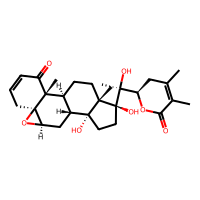
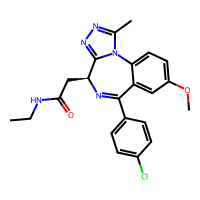
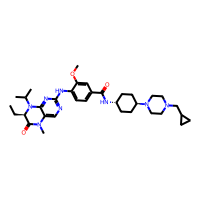

In [6]:
df = pd.read_pickle("../data/01_brd4_all_inhibitors.pkl")
df.set_index('ID', inplace=True)
print(len(df))
render_mol(df.head(3))

## Morgan fingerprints

From the [SALI analysis](../01_eda/02_activity_cliffs.ipynb) we know that `radius = 3` is important for this data set. 

The method `utils.similarity_sali.MorganSimilarity.get_morgan_fingerprint()` is used to calculate the fingerprints. 

In [7]:
### Number of Morgan fingerprints (features)
n_bits = 2048

### Instantiate the class
morgan = MorganSimilarity(df, radius=3, nBits=n_bits, useChirality=True)

### Get the Morgan fingerprints
morgan.get_morgan_fingerprint()

### Format the fingerprints as NumPy array
morgan.format_fp("DataFrame")

morgan.fp

,0,1,2,3,4,5,6,7,8,9,...,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047
ID,,,,,,,,,,,,,,,,,,,,,
CHEMBL1097107,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CHEMBL1232461,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CHEMBL1233528,0,1,0,0,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
CHEMBL1287853,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CHEMBL1313432,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CHEMBL5440963,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CHEMBL848,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CHEMBL9,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Data Split
To reduce computational cost a validation set is generated in a addition to training and test ses rather than performing cross-validation. Equal activity distribution is ensured by binning and stratified sampling.   

In [9]:
### Create bins for stratification
df["bins"] = pd.qcut(df["pIC50"], q=10, labels=False)

### Generate the training set
X_train_fp, X_temp_fp, y_train, y_temp = sk.model_selection.train_test_split(
    morgan.fp,
    df["pIC50"],
    test_size=0.3,
    random_state=SEED,
    stratify=df["bins"],
)

### Generate the validation and test sets
X_val_fp, X_test_fp, y_val, y_test = sk.model_selection.train_test_split(
    X_temp_fp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=df.loc[y_temp.index, "bins"],
)

In [10]:
print("train.shapes:", X_train_fp.shape, y_train.shape)
print("val.shapes:", X_val_fp.shape, y_val.shape)
print("test.shapes:", X_test_fp.shape, y_test.shape)

train.shapes: (2044, 2048) (2044,)
val.shapes: (438, 2048) (438,)
test.shapes: (438, 2048) (438,)


## Dimensionality Reduction
Principal component analysis (PCA) is used to reduce data complexity. A more detailed variance analysis for the same data set using PCA is demonstrated in [feature selection for classification with random forests](../03_QSAR_classifier/01_feature_selection.ipynb). For classification `32 PCs` were used. The dimensionality can be chosen by subsetting the the corresponding number of columns.  

In [19]:
### Instantiate the PCA class
pca = sk.decomposition.PCA(random_state=SEED)

### Perform PCA model
X_train_2048 = pd.DataFrame(pca.fit_transform(X_train_fp), index=X_train_fp.index)
X_val_2048 = pd.DataFrame(pca.transform(X_val_fp), index=X_val_fp.index)
X_test_2048 = pd.DataFrame(pca.transform(X_test_fp), index=X_test_fp.index)

In [17]:
print("train.shapes:", X_train_2048.shape)
print("val.shapes:", X_val_2048.shape)
print("test.shapes:", X_test_2048.shape)

train.shapes: (2044, 2044)
val.shapes: (438, 2044)
test.shapes: (438, 2044)


## Data Loader
The datasets converted to the native format of PyTorch. The `batch_size` is a tunable hyperparameter.  

In [29]:
def df_to_dataloader(X, y, batch_size=32, n_features=32, shuffle=True):
    """
    Convert a pandas DataFrame to a PyTorch DataLoader.

    Parameters
    ----------
    X : pandas.DataFrame
        Features
    y : pandas.Series
        Target
    batch_size : int
        Number of samples per batch
    n_features : int
        Number of features to use
    shuffle : bool
        Shuffle the data
    
    Returns
    -------
    DataLoader
    """
    dataset = TensorDataset(
        torch.tensor(X.iloc[:, :n_features].to_numpy(), dtype=torch.float32).to(device),
        torch.tensor(y.to_numpy(), dtype=torch.float32).view(-1, 1).to(device),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

In [33]:
### Use GPU if available
device = "cuda:3" if torch.cuda.is_available() else "cpu"
### Number of features
n_features = 512

### PyTorch DataLoaders
train_loader = df_to_dataloader(X_train_2048, y_train, batch_size=32, n_features=n_features, shuffle=True)
val_loader = df_to_dataloader(X_val_2048, y_val, batch_size=32, n_features=n_features, shuffle=False)
test_loader = df_to_dataloader(X_test_2048, y_test, batch_size=32, n_features=n_features, shuffle=False)

# Model Architecture
A network with two hidden layers and adjustable layer width (n_hidden). 

In [31]:
### Define the model architecture
class Net(torch.nn.Module):
    def __init__(self, n_features, n_hidden1, n_hidden2):
        super(Net, self).__init__()
        self.fc1 = torch.nn.Linear(n_features, n_hidden1)
        self.fc2 = torch.nn.Linear(n_hidden1, n_hidden2)
        self.fc3 = torch.nn.Linear(n_hidden2, 1)

    def forward(self, x):
        x = torch.nn.functional.relu(self.fc1(x))
        x = torch.nn.functional.relu(self.fc2(x))
        x = self.fc3(x)
        return x

## Training Loop

In [83]:
def training_loop(
    n_epochs,
    eval_interval,
    model,
    optimizer,
    train_loader=test_loader,
    test_loader=test_loader,
    plot=True,
):
    """
    Training loop with evaluation for a PyTorch model

    Parameters
    ----------
    n_epochs : int
        Number of epochs to train the model
    eval_interval : int
        Interval to evaluate the model
    model : torch.nn.Module
        PyTorch model to train
    optimizer : torch.optim.Optimizer
        PyTorch optimizer to use
    train_loader : torch.utils.data.DataLoader
        DataLoader for the training set
    test_loader : torch.utils.data.DataLoader
        DataLoader for the test set
    
    Returns
    -------
    error_df : pd.DataFrame
        DataFrame with the train loss and test error
    """

    ### Set the network to training mode
    model.train()

    ### Define the loss function
    criterion = torch.nn.MSELoss()

    ### Initialize the error metric
    rmse = torchmetrics.regression.MeanSquaredError().to(device)

    ### DataFrame to store the train loss and test error
    error_df = pd.DataFrame(
        {
            "epoch": range(n_epochs),
            "train_loss": np.nan,
            "test_error": np.nan,
        }
    ).set_index("epoch")

    ### Training loop
    for epoch in tqdm(range(n_epochs)):
        ### Initialize running loss
        running_loss = 0.0


        # # #  T R A I N I N G   B L O C K 
        for batch_X, batch_Y in train_loader:
            ### Move the data to the appropriate device
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)

            ### Set the parameter gradients to zero
            optimizer.zero_grad()

            ### Forward the training data through the model cnn
            output = model(batch_X)

            ### Compute the loss
            loss = criterion(output, batch_Y)

            ### Add the loss to the running loss
            running_loss += loss.item()

            ### Compute the gradients by applying a backward() step to the calculated loss
            loss.backward()

            ### Perform an optimization step by applying step() to your optimizer
            optimizer.step()

        ### Save the training loss
        error_df.loc[epoch, "train_loss"] = running_loss / len(train_loader)


        # # #  E V A L U A T I O N   B L O C K
        if epoch % eval_interval == 0 or epoch == n_epochs - 1:
            ### Set the model in evaluation
            model.eval()

            ### Disable gradient computation
            with torch.no_grad():
                ### Loop over the DataLoader
                for batch_X, batch_Y in test_loader:
                    ### Move the data to the appropriate device
                    batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)

                    ### Forward the training data through the model cnn
                    output = model(batch_X)

                    ### Compute the accuracy
                    rmse.update(output, batch_Y)

            ### Compute the test error
            error_df.loc[epoch, "test_error"] = rmse.compute().item()
            
            ### Reset the metric
            rmse.reset()

            ### Set the model back to training
            model.train()

    ### Convert MSEs to RMSEs for interpretation
    error_df["train_loss"] = np.sqrt(error_df["train_loss"])
    error_df["test_error"] = np.sqrt(error_df["test_error"])

    return error_df

# Feature selection

## Overfitting
Initially the training data is overfitted to demonstrate that the problem (predicting pIC50 values from 512 principal components) is solvable. This is achieved as the test error from the validation set plateaus while the training error still decreases.

In [87]:
### Instantiate the model
net = Net(
    n_features=n_features,  # Number of features (principal components)
    n_hidden1=64,          # Number of neurons in the first hidden layer
    n_hidden2=32,           # Number of neurons in the second hidden layer
).to(device)                # Create the network and send it to the device

### Define the optimizer
optim = torch.optim.Adam(
    net.parameters(),  # Parameters to optimize
    lr=1e-4,  # Learning rate
    weight_decay=0,  # L2/Ridge regularization
)

### Training loop
error_df = training_loop(
    model=net,
    optimizer=optim,
    n_epochs=1000,
    eval_interval=50,
    train_loader=train_loader,
    test_loader=val_loader,
)

100%|██████████| 1000/1000 [01:29<00:00, 11.17it/s]


smallest test error: 0.67 @ epoch: 400


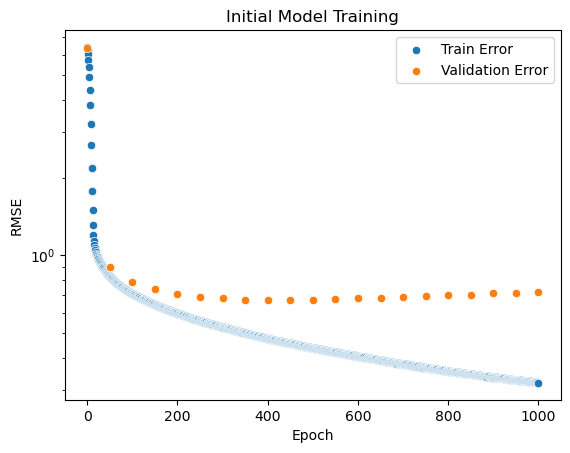

In [100]:
print(f"smallest test error: {error_df['test_error'].min():.2f} @ epoch: {error_df['test_error'].idxmin()}")

### Plot 
sns.scatterplot(data=error_df, x="epoch", y="train_loss", label="Train Error")
sns.scatterplot(data=error_df, x="epoch", y="test_error", label="Validation Error")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.yscale("log")
plt.legend()
plt.title("Initial Model Training")
plt.show()

## Dimensionality

In [97]:
def screen_dims(n_features):
    """
    Train the model with the given number of features and return the final train loss and test error.

    Parameters
    ----------
    n_features : int
        Number of features to use
    
    Returns
    -------
    pd.Series
        Final train loss and test error
    """

    ### PyTorch DataLoaders
    train_loader = df_to_dataloader(X_train_2048, y_train, batch_size=32, n_features=n_features, shuffle=True)
    val_loader = df_to_dataloader(X_val_2048, y_val, batch_size=32, n_features=n_features, shuffle=False)

    ### Instantiate the model
    net = Net(
        n_features=n_features,  # Number of features (principal components)
        n_hidden1=64,          # Number of neurons in the first hidden layer
        n_hidden2=32,           # Number of neurons in the second hidden layer
    ).to(device)                # Create the network and send it to the device

    ### Define the optimizer
    optim = torch.optim.Adam(
        net.parameters(),  # Parameters to optimize
        lr=1e-4,  # Learning rate
        weight_decay=0,  # L2/Ridge regularization
    )

    ### Training loop
    error_df = training_loop(
        model=net,
        optimizer=optim,
        n_epochs=400,
        eval_interval=400,
        train_loader=train_loader,
        test_loader=val_loader,
        plot=False,
    )

    return tuple(error_df[["train_loss", "test_error"]].iloc[-1])


In [98]:
dims_df = pd.DataFrame({
        "n_features": [8, 32, 128, 512],
})
dims_df[["train_loss", "test_error"]] = dims_df["n_features"].apply(screen_dims).apply(pd.Series)


  0%|          | 0/400 [00:00<?, ?it/s]

100%|██████████| 400/400 [00:49<00:00,  8.12it/s]


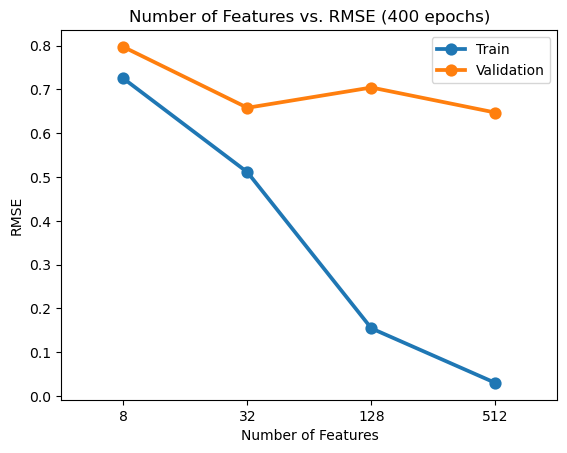

In [102]:
### Plot the results
sns.pointplot(data=dims_df, x="n_features", y="train_loss", label="Train")
sns.pointplot(data=dims_df, x="n_features", y="test_error", label="Validation")
plt.xlabel("Number of Features")
plt.ylabel("RMSE")
plt.title("Number of Features vs. RMSE (400 epochs)")
plt.legend()
plt.show()

# Hyperparameter-tuning

In [104]:
def objective(trial):
    """
    Objective function for Bayesian Optimization
    """
    
    ### Sample hyperparameters
    n_hidden1 = trial.suggest_categorical('n_hidden1', [16, 32, 64])
    n_hidden2 = trial.suggest_categorical('n_hidden2', [8, 16, 32])
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    ### Instantiate model
    net = Net(
        n_features=n_features,
        n_hidden1=n_hidden1,
        n_hidden2=n_hidden2,
    ).to(device)

    # Optimizer
    optimizer = torch.optim.Adam(
        net.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    ### DataLoader with tuned batch size
    train_loader = df_to_dataloader(X_train_2048, y_train, batch_size=batch_size, n_features=n_features, shuffle=True)
    val_loader = df_to_dataloader(X_val_2048, y_val, batch_size=batch_size, n_features=n_features, shuffle=False)

    ### Train the model
    error_df = training_loop(
        model=net,
        optimizer=optimizer,
        n_epochs=50,                    # Fixed as per your earlier decision
        eval_interval=50,               # Less frequent evaluation for faster tuning
        test_loader=val_loader,
        train_loader=train_loader,
    )

    ### Return the final test RMSE for evaluation
    return error_df['test_error'].iloc[-1]


In [105]:
## Number of features
n_features = 32

### Create the study
study = optuna.create_study(direction='minimize')  # Minimize RMSE

# Run optimization
study.optimize(objective, n_trials=10)

# Display best results
print("Best hyperparameters:", study.best_params)
print("Best RMSE:", study.best_value)

[I 2025-03-24 10:56:45,113] A new study created in memory with name: no-name-af497c2b-6cc9-4545-9704-74f60d12492b
100%|██████████| 50/50 [00:05<00:00,  8.85it/s]
[I 2025-03-24 10:56:50,778] Trial 0 finished with value: 0.8430433846596666 and parameters: {'n_hidden1': 64, 'n_hidden2': 32, 'learning_rate': 0.00012338211367094874, 'weight_decay': 0.0001747562778048789, 'batch_size': 32}. Best is trial 0 with value: 0.8430433846596666.
100%|██████████| 50/50 [00:09<00:00,  5.24it/s]
[I 2025-03-24 10:57:00,328] Trial 1 finished with value: 2.2784891012875788 and parameters: {'n_hidden1': 64, 'n_hidden2': 8, 'learning_rate': 1.8638850989461258e-05, 'weight_decay': 0.00026284352950636553, 'batch_size': 16}. Best is trial 0 with value: 0.8430433846596666.
100%|██████████| 50/50 [00:08<00:00,  5.64it/s]
[I 2025-03-24 10:57:09,200] Trial 2 finished with value: 1.026221006311438 and parameters: {'n_hidden1': 32, 'n_hidden2': 32, 'learning_rate': 2.951402182654489e-05, 'weight_decay': 0.0005831537

Best hyperparameters: {'n_hidden1': 64, 'n_hidden2': 16, 'learning_rate': 0.0006461508554792975, 'weight_decay': 0.0005595951887968704, 'batch_size': 32}
Best RMSE: 0.7256364560927377


In [106]:
optuna.visualization.plot_optimization_history(study)


In [107]:
optuna.visualization.plot_param_importances(study)
